In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv(r"C:\Users\Lenovo\Desktop\mlops\data\StudentPerformanceFactors.csv")
print(df.head(1))
# shapes and types
print(df.shape)
print(df.columns)
print(df.dtypes.value_counts())
strings= df.select_dtypes(include='object').columns
nums = df.select_dtypes(include='number').columns

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Yes                  0           Low          Medium   

  School_Type Peer_Influence  Physical_Activity Learning_Disabilities  \
0      Public       Positive                  3                    No   

  Parental_Education_Level Distance_from_Home Gender  Exam_Score  
0              High School               Near   Male          67  
(6607, 20)
Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quali

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10640\3986971442.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  strings= df.select_dtypes(include='object').columns


In [2]:
# missing and duplicates
# print(f'the dupliacates are {df.duplicated().value_counts()}')
# print(f'the missing values are {df.isna().sum()}')
# print(f'now removing the nan values')
for col in df.columns:
    missing = df[col].isna().sum()  # df[col] not df
    pct = (missing / len(df)) * 100
    if missing == 0:
        pass
    elif pct <= 5:
        print(f'{col}: {pct:.1f}% → impute')
    elif pct <= 30:
        print(f'{col}: {pct:.1f}% → impute carefully')
    else:
        print(f'{col}: {pct:.1f}% → drop')
for col in nums:
    if df[col].isna().sum() >=1:
        df[col] = df[col].fillna(df[col].median(),inplace=True)


Teacher_Quality: 1.2% → impute
Parental_Education_Level: 1.4% → impute
Distance_from_Home: 1.0% → impute


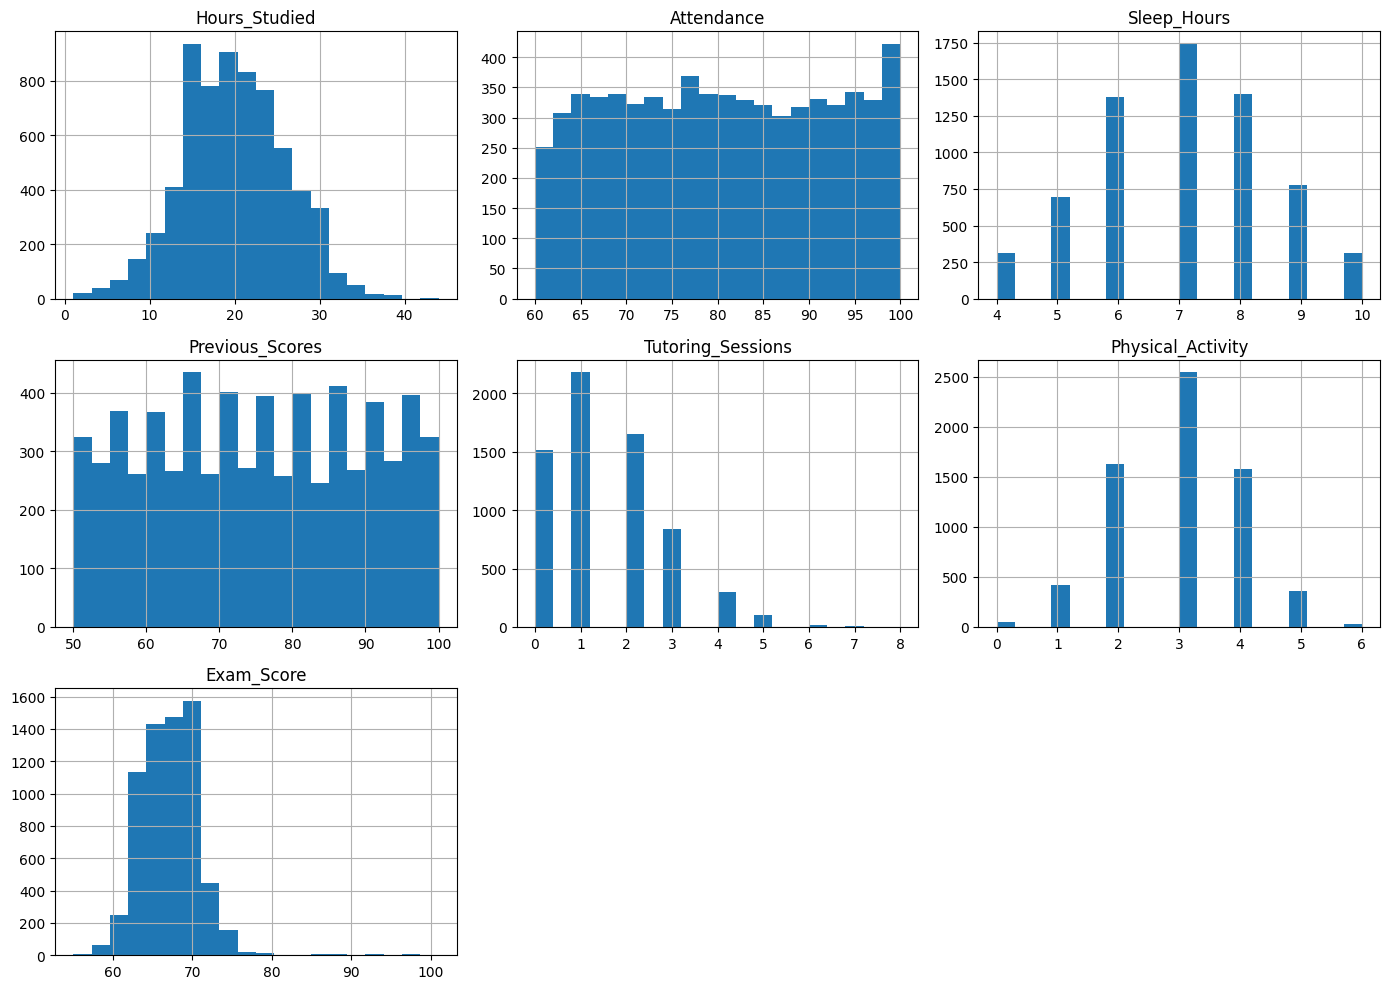

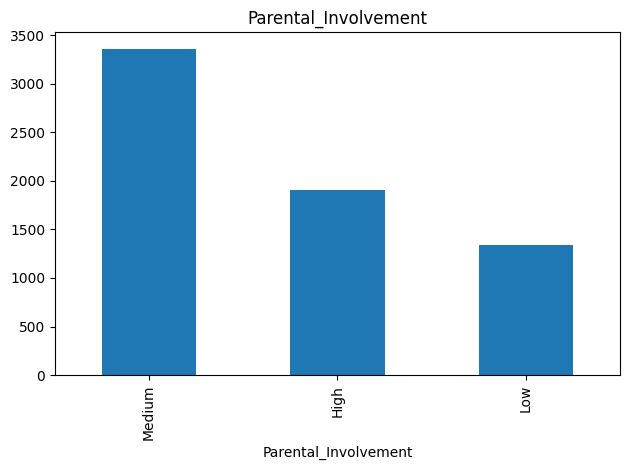

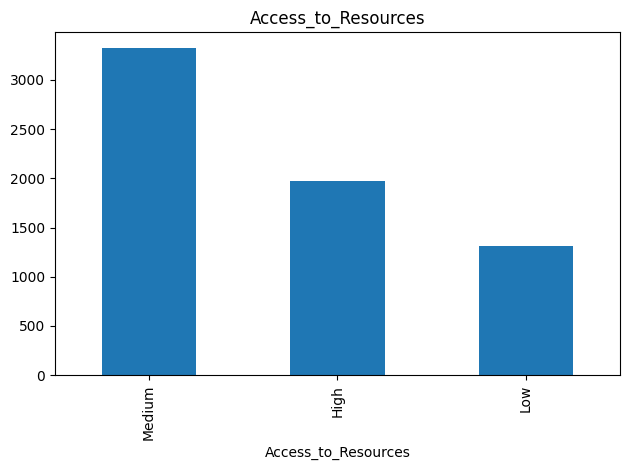

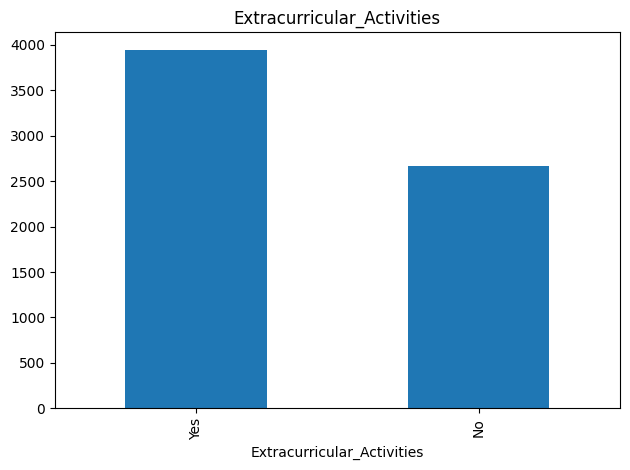

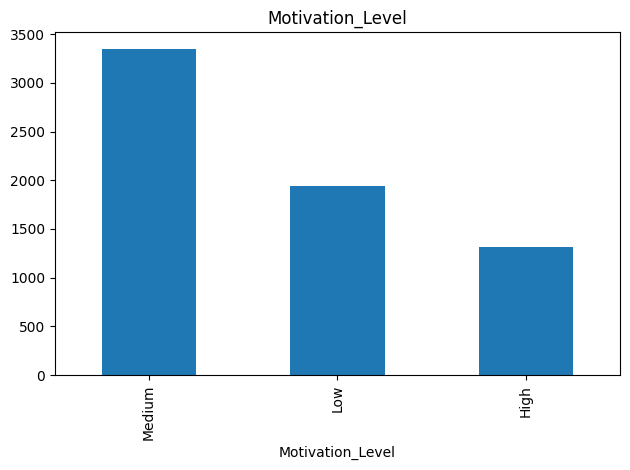

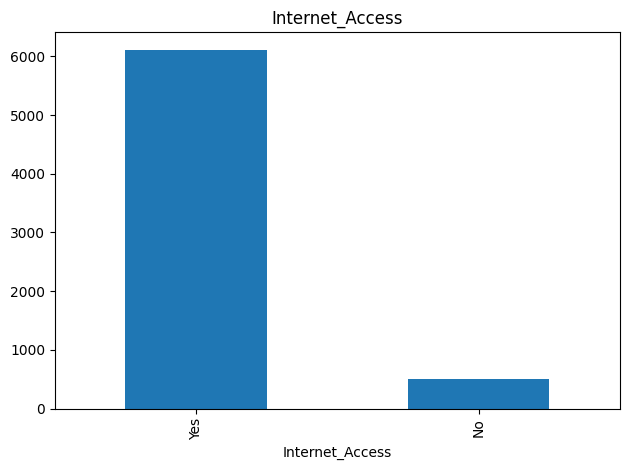

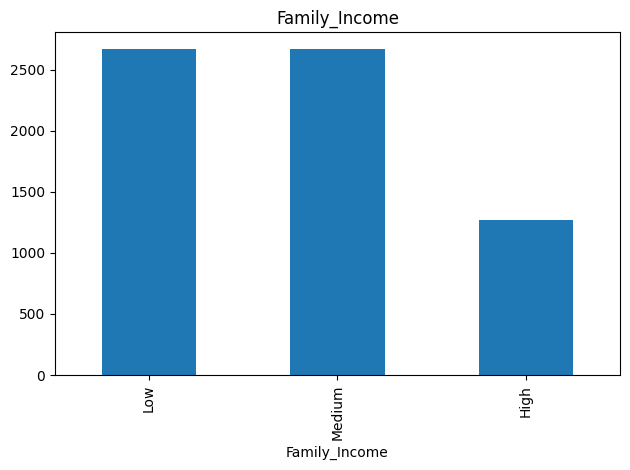

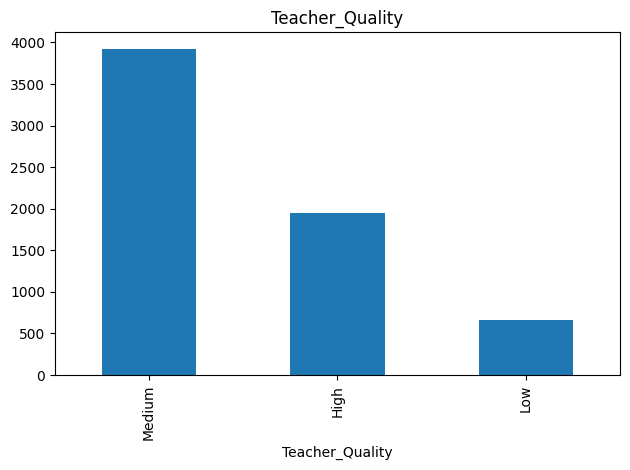

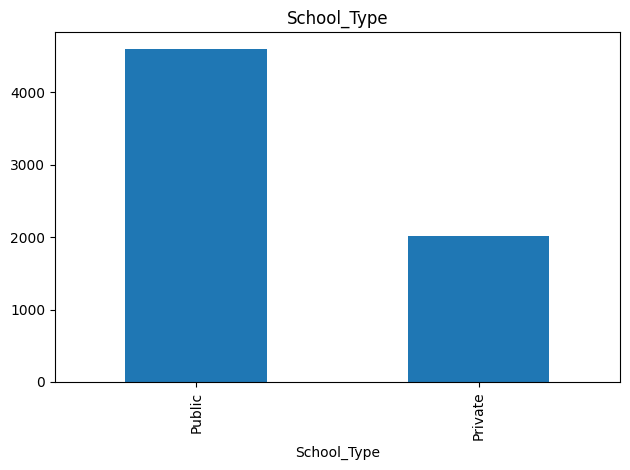

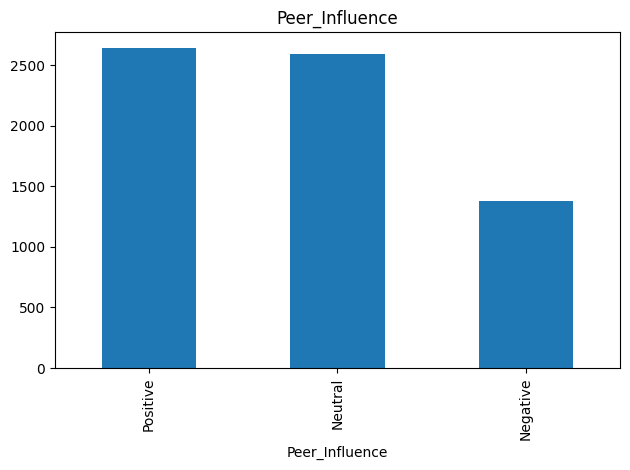

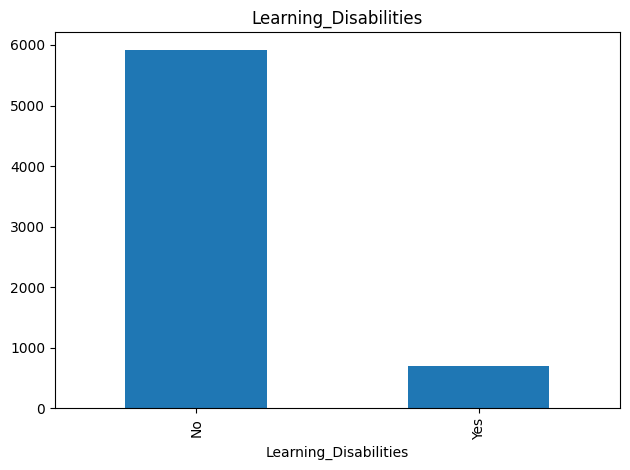

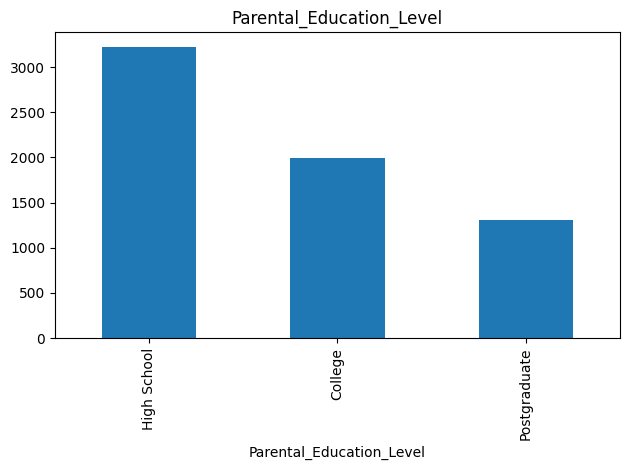

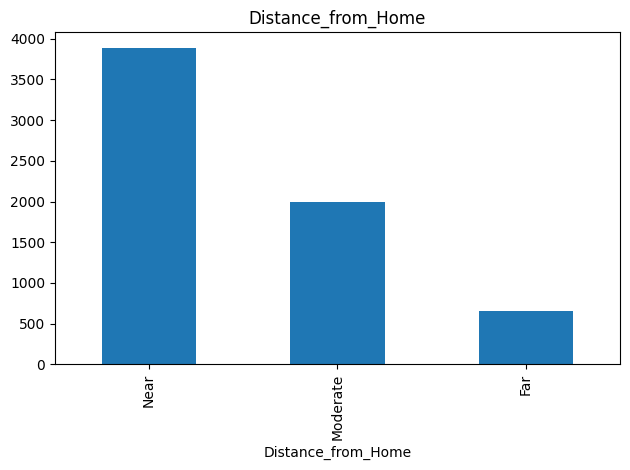

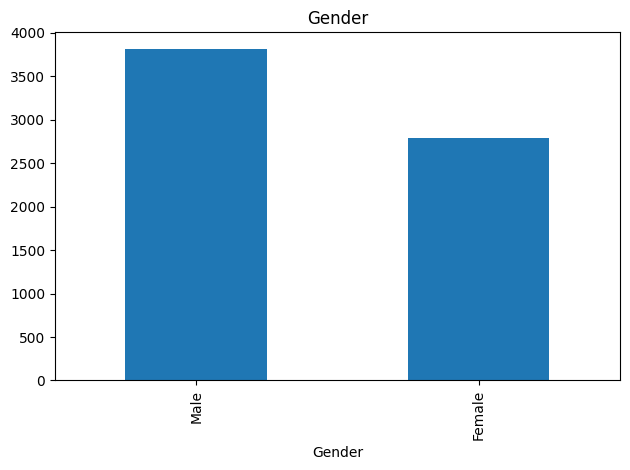

In [3]:
# stage3 of showing distribution
import matplotlib.pyplot as plt
import seaborn as sns
# Numerical distributions — how is each column spread?
df[nums].hist(figsize=(14,10), bins=20)
plt.tight_layout()
plt.show()

# Categorical distributions — how frequent is each category?
for col in strings:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.tight_layout()
    plt.show()


now showing the parental level <StringArray>
['High School', 'College', 'Postgraduate', nan]
Length: 4, dtype: str


Gender
Male      0.577267
Female    0.422733
Name: proportion, dtype: float64

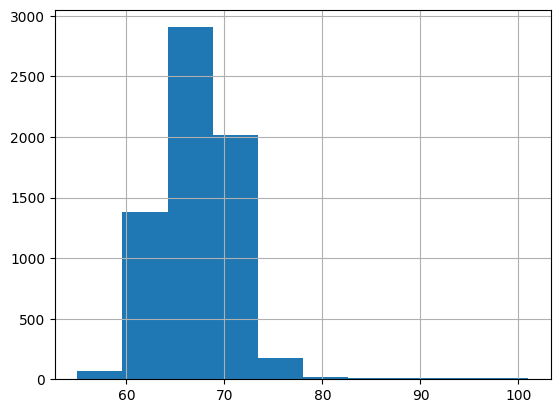

In [4]:
print(f'now showing the parental level',end=' ')
print(df['Parental_Education_Level'].unique())
df['Exam_Score'].hist()  # visual confirmation
df[col].value_counts(normalize=True)  # as percentages, easier to read


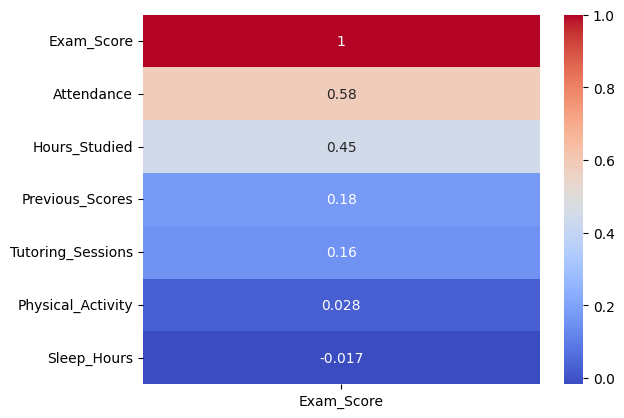

In [5]:
corr = df[nums].corr()
sns.heatmap(corr[['Exam_Score']].sort_values('Exam_Score', ascending=False),
            annot=True, cmap='coolwarm')
plt.show()

In [6]:
print(strings)

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='str')


In [10]:
import numpy as np
for col in nums:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 -q1
    outliers = df[(df[col]<q1 -1.5*iqr) | (df[col] > q3 + 1.5*iqr)]
    print(f'{col}: {len(outliers)} outliers')

Hours_Studied: 43 outliers
Attendance: 0 outliers
Sleep_Hours: 0 outliers
Previous_Scores: 0 outliers
Tutoring_Sessions: 430 outliers
Physical_Activity: 0 outliers
Exam_Score: 104 outliers
